In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from arte.math.toccd import toccd

In [2]:
def rebin(a, shape):
    sh = shape[0],a.shape[0]//shape[0],shape[1],a.shape[1]//shape[1]
    return a.reshape(sh).mean(-1).mean(1)
    # return toccd(a,shape)

def reshape_on_mask(a,mask):
    img_2d = np.zeros(mask.shape)
    img_2d[~mask] = a.copy()
    img_2d = img_2d.reshape(mask.shape)
    return img_2d

In [3]:
if_path = '/mnt/libero/SPLATTData/Data/OPTData/IFFunctions'
im_path = '/mnt/libero/SPLATTData/Data/OPTData/IntMatrices'
raw_img_path = '/mnt/libero/SPLATTData/Data/OPTData/OPDImages'
tn = '20250819_164905'

hdu = fits.open(os.path.join(im_path,tn,'IMCube.fits'))
IMcube = hdu[0].data
masks = hdu[1].data

In [4]:
# mask_shape = (IMcube.shape[0],IMcube.shape[1])
# master_mask = np.zeros(mask_shape,dtype=bool)
# for k in range(IMcube.shape[-1]):
#     master_mask = np.logical_or(master_mask,masks[:,:,k])

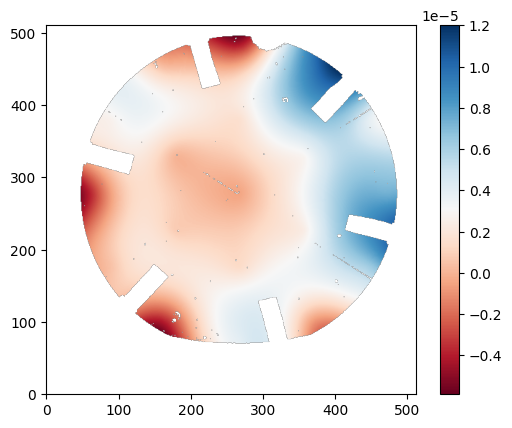

In [5]:
Nacts = 19
N = 3*Nacts

# Define master mask
mask_shape = (IMcube.shape[0],IMcube.shape[1]) #(128,128)
master_mask = np.zeros(mask_shape,dtype=bool)
for k in range(N):
    hdu = fits.open(os.path.join(raw_img_path,tn,f'image_{k:05}.fits'))
    mask = hdu[1].data.copy()
    mask_rebin = rebin(mask,mask_shape)
    master_mask = np.logical_or(master_mask,mask_rebin)

avg_img = np.zeros(np.sum(1-master_mask))
# Define average image
for k in range(N):
    hdu = fits.open(os.path.join(raw_img_path,tn,f'image_{k:05}.fits'))
    img = hdu[0].data.copy()
    img_rebin = rebin(img,mask_shape)
    avg_img += img_rebin[~master_mask]/N

# avg_img = np.nanmean(img_rebin,axis=0)
avg_img_2d = reshape_on_mask(avg_img, master_mask)

plt.figure()
plt.imshow(np.ma.masked_array(avg_img_2d,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()

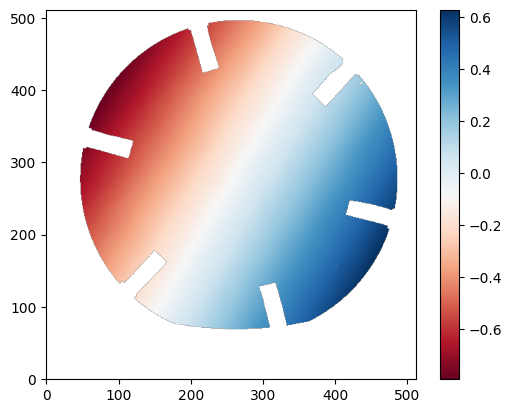

In [6]:
plt.figure()
plt.imshow(np.ma.masked_array(IMcube[:,:,1],mask=masks[:,:,1]),origin='lower',cmap='RdBu')
plt.colorbar()

In [7]:
IF = np.zeros([np.sum(1-master_mask),Nacts],dtype=float)
for j in range(Nacts):
    im = rebin(IMcube[:,:,j],mask_shape)
    IF[:,j] = im[~master_mask]

In [8]:
U,D,Vt = np.linalg.svd(IF,full_matrices=False)
R = (Vt.T * 1/D) @ U.T

Text(0.5, 1.0, 'Residual shape\nRMS=586.3nm')

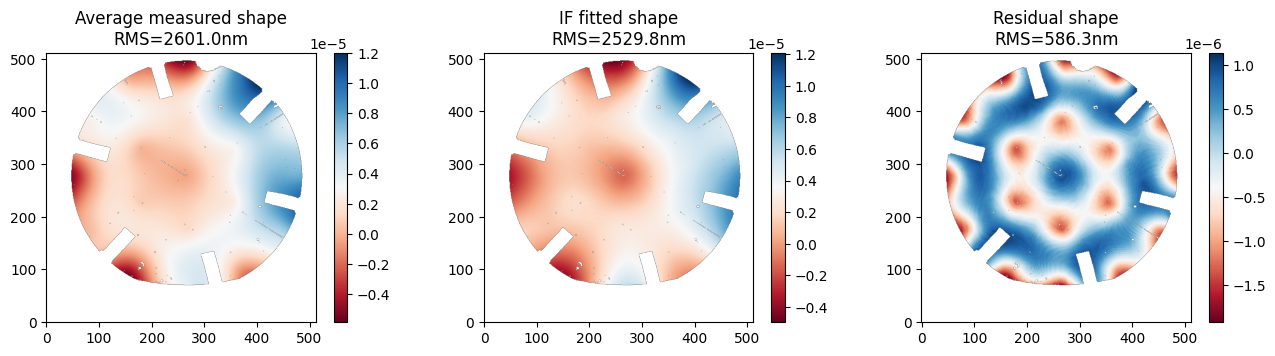

In [9]:
coeffs = R @ avg_img
fit_img = IF @ coeffs

fit_img_2d = reshape_on_mask(fit_img,master_mask)
diff = avg_img_2d-fit_img_2d
diff -= np.mean(diff)

plt.figure(figsize=(16,3.5))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(avg_img_2d,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Average measured shape\nRMS={np.std(avg_img_2d[~master_mask])*1e+9:1.1f}nm')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(fit_img_2d,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'IF fitted shape\nRMS={np.std(fit_img_2d[~master_mask])*1e+9:1.1f}nm')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(diff,mask=master_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title(f'Residual shape\nRMS={np.std(diff[~master_mask])*1e+9:1.1f}nm')

In [10]:
from scipy.interpolate import Rbf

# Extrapolate missing data in image using thin-plate-spline interpolation
binned_shape = (128,128)
img_rebin = rebin(diff,binned_shape)
mask_rebin = rebin(master_mask,binned_shape)

# Extract valid (non-masked) pixel coordinates and values
valid_mask = ~mask_rebin.astype(bool)
y_valid, x_valid = np.where(valid_mask)
z_valid = img_rebin[valid_mask]

# Create RBF interpolator with thin-plate spline
rbf = Rbf(x_valid, y_valid, z_valid, function='thin_plate', smooth=0)

# Evaluate RBF on full grid to fill holes
Y, X = np.mgrid[0:img_rebin.shape[0], 0:img_rebin.shape[1]]
diff_fill = rbf(X, Y)


Text(0.5, 1.0, 'Difference')

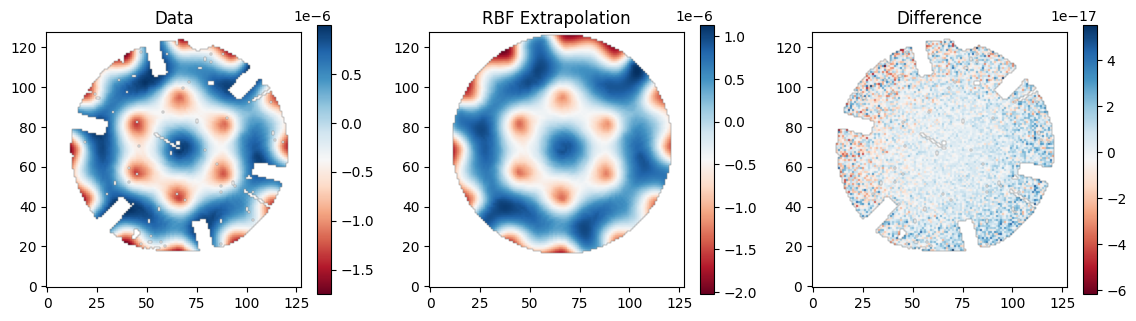

In [11]:
rho = lambda x,y, xc, yc: np.sqrt((x-xc)**2+(y-yc)**2)
mask_fill = np.fromfunction(lambda i,j: rho(i,j,71,66)>=440/4/2, img_rebin.shape).astype(bool)

# Optionally show the filled image
plt.figure(figsize=(14, 3.5))
plt.subplot(1, 3, 1)
plt.imshow(np.ma.masked_array(img_rebin, mask=mask_rebin), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('Data')
plt.subplot(1, 3, 2)
plt.imshow(np.ma.masked_array(diff_fill, mask=mask_fill), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('RBF Extrapolation')
plt.subplot(1, 3, 3)
plt.imshow(np.ma.masked_array(diff_fill-img_rebin, mask=mask_rebin), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('Difference')

In [ ]:
pix_scale = 400e-3/428 # m/pix

def simulate_ibf(img, fwhm:float, mask=master_mask, amp:float=1e-8, pix_scale:float=pix_scale):

    # Gaussian removal function
    sigma = fwhm/pix_scale/(np.sqrt(np.log(2**8)))

    X,Y = np.mgrid[0:img.shape[0],0:img.shape[1]]
    X -= (np.max(X)-np.min(X))//2
    Y -= (np.max(Y)-np.min(Y))//2
    rf = 1/(2*np.pi*sigma**2)*np.exp(-(X**2+Y**2)/(2*sigma**2))
    rf *= amp

    # plt.figure()
    # plt.imshow(rf,origin='lower',cmap='Blues')
    # plt.colorbar()
    # plt.title('Gaussian removal function')

    # Deconvolution
    img_ft = np.fft.fft2(img)
    rf_ft = np.fft.fft2(rf)

    noise_power = amp  # adjust based on noise level
    denominator = np.abs(rf_ft)**2 + noise_power
    deconv_ft = img_ft * np.conj(rf_ft) / denominator
    deconv = np.fft.ifft2(deconv_ft)
    removed = np.fft.fftshift(deconv.real)

    ibf_img = img-removed
    if_coeffs = R @ ibf_img[~mask]
    rec_ibf = reshape_on_mask(IF @ if_coeffs,mask)
    ibf_fit = ibf_img - rec_ibf

    plt.figure(figsize=(17,3.5))
    plt.subplot(1,4,1)
    plt.imshow(np.ma.masked_array(img,mask=mask), origin='lower', cmap='RdBu')
    plt.colorbar()
    plt.title(f'Before IBF\nRMS={np.std(img[~mask])*1e+9:1.1f}nm')
    plt.subplot(1,4,2)
    plt.imshow(np.ma.masked_array(removed,mask=mask), origin='lower', cmap='RdBu')
    plt.colorbar()
    plt.title(f'Removed material\nRMS={np.std(removed[~mask])*1e+9:1.1f}nm')
    plt.subplot(1,4,3)
    plt.imshow(np.ma.masked_array(ibf_img,mask=mask), origin='lower', cmap='RdBu')
    plt.colorbar()
    plt.title(f'After IBF\nRMS={np.std(ibf_img[~mask])*1e+9:1.1f}nm')
    plt.subplot(1,4,4)
    plt.imshow(np.ma.masked_array(ibf_fit,mask=mask), origin='lower', cmap='RdBu')
    plt.colorbar()
    plt.title(f'After IBF and IF fitting\nRMS={np.std(ibf_fit[~mask])*1e+9:1.1f}nm')
    return ibf_img

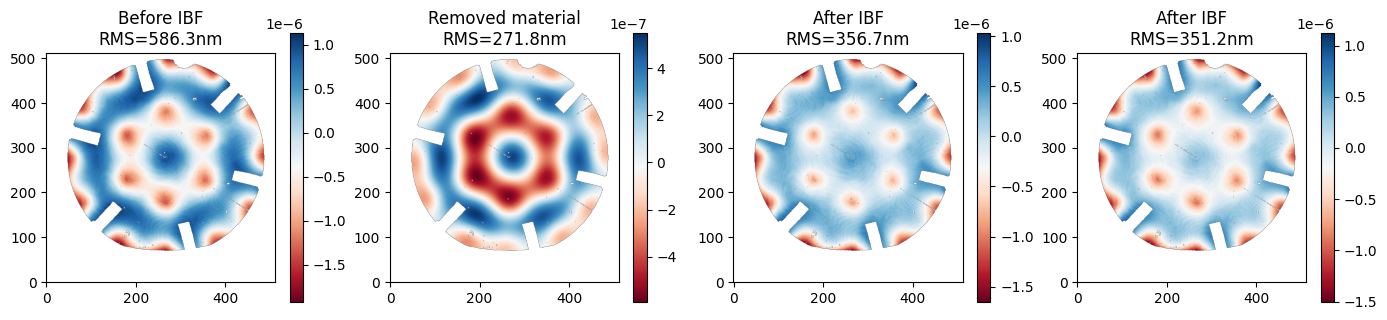

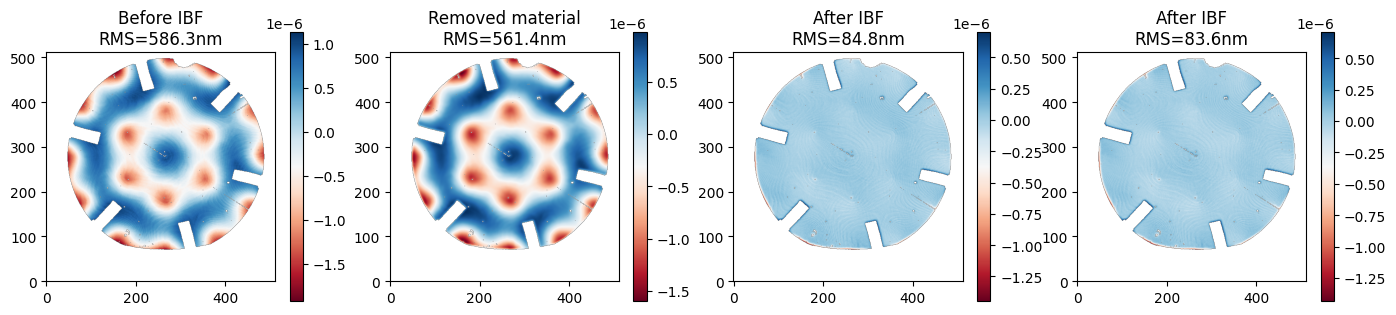

In [13]:
ibf50_img = simulate_ibf(diff, fwhm=50e-3)
ibf5_img = simulate_ibf(diff, fwhm=5e-3)

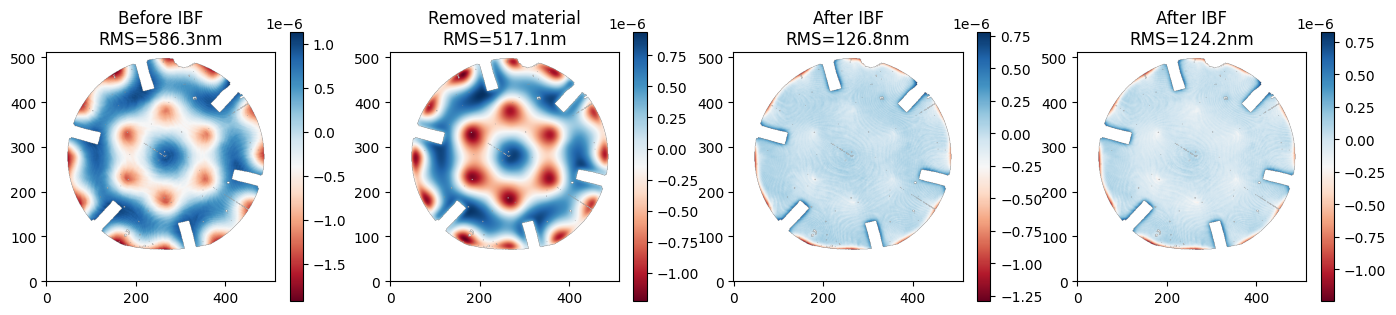

In [14]:
fwhm = 13e-3
ibf13_img = simulate_ibf(diff, fwhm=fwhm)

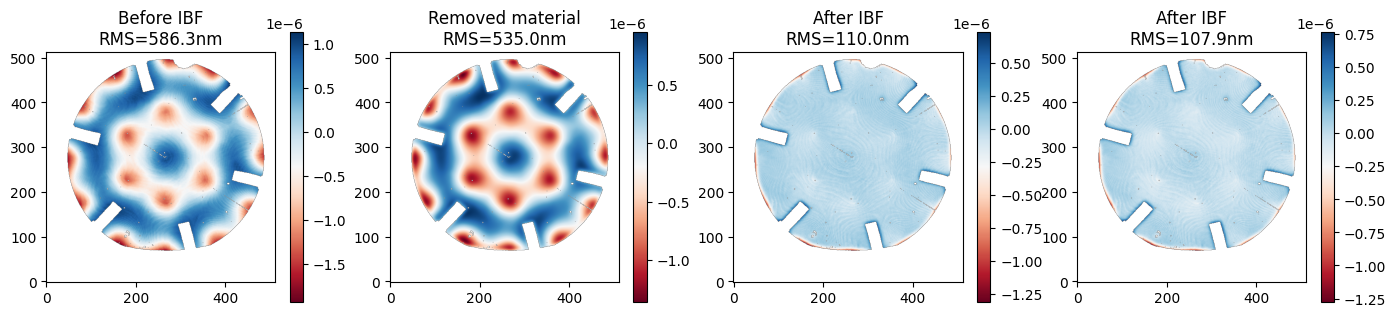

In [16]:
fwhm = 10e-3
ibf10_img = simulate_ibf(diff, fwhm=fwhm)

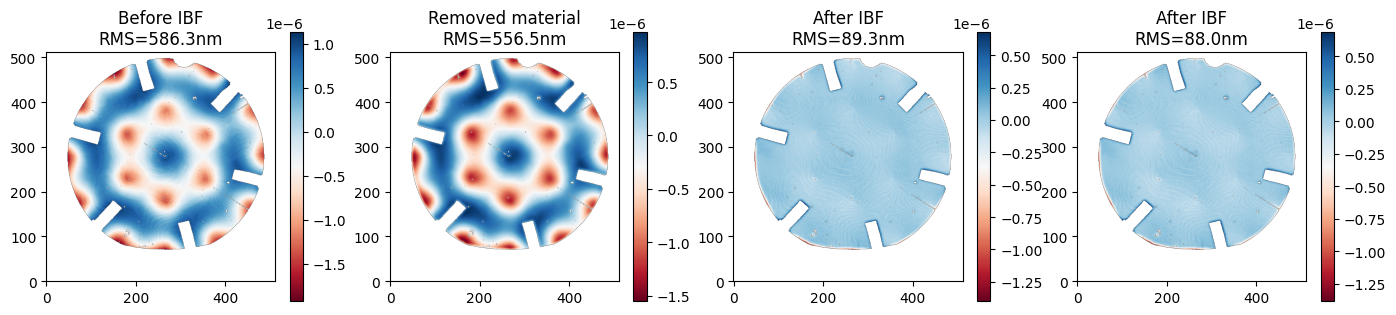

In [17]:
fwhm = 6e-3
ibf6_img = simulate_ibf(diff, fwhm=fwhm)

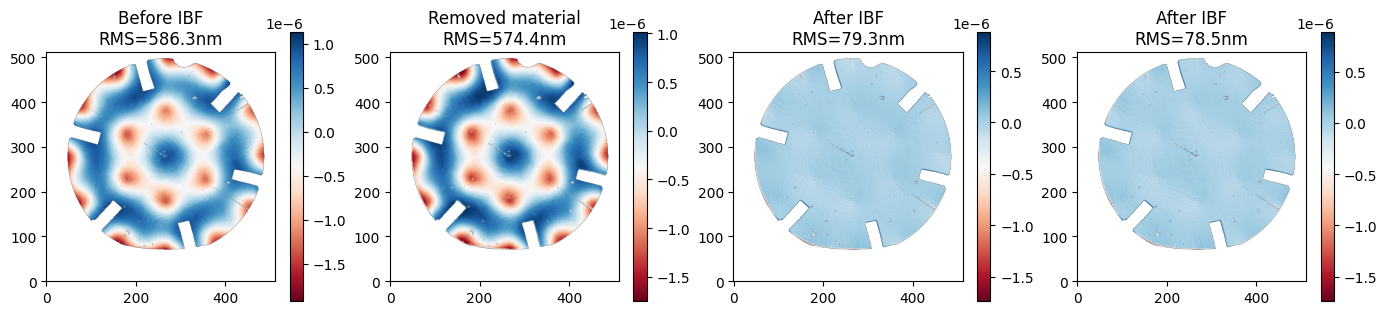

In [18]:
fwhm = 2e-3
ibf2_img = simulate_ibf(diff, fwhm=fwhm)

In [19]:
def get_photocenter(image):
    ny, nx = image.shape
    x,y = np.arange(nx), np.arange(ny)
    X,Y = np.meshgrid(x, y)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    return qx,qy 

In [ ]:
import scipy
import scipy.stats as stats
def comp_psd(timg, mask, verbose=False, normalize=True):

    # reshape and pad

    sz = max(timg.shape)
    npix = sz**2
    
    img = timg * mask
    tf2d = scipy.fft.ifft2(img,norm='ortho') #fft2(img,norm='ortho')
    
    if np.abs(np.mean(img[mask==1])) > 1e-9:
        print("Warning: piston not removed %g" % np.abs(np.mean(img[mask==1])))
        verbose=1
    orig_tf2d = np.abs(tf2d[0,0])
    tf2d_power_spectrum = np.abs(tf2d)**2

    kfreq = np.fft.fftfreq(sz)                 #freq spaziale in 1/pixel
    kfreq2D = np.meshgrid(kfreq, kfreq)            #griglia di frequenze xx e yy
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)  #griglia di frequenze distanza

    knrm = knrm.flatten()
    fourier_amplitudes = tf2d_power_spectrum.flatten()
    kbins = kfreq[0:sz//2+1]
    kbins[-1] = max(kbins)+kbins[1]
    
    Abins, _, _  = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "sum",
                                         bins = kbins)
    ediff = (np.sum(img[mask==1]**2) - np.sum(Abins))/np.sum(img[mask==1]**2)

    #normalize energy
    rmsima = np.sqrt(np.sum(img**2)/npix)
    rmsbs = np.sqrt(np.sum(Abins*(kfreq[1]**2)))
    rmspsd = np.sqrt(np.sum(tf2d_power_spectrum*(kfreq[1]**2)))
    rmsmasked = np.sqrt(np.sum(img[mask==1]**2/np.sum(mask)))
    Abins_normalized = Abins * (rmsmasked/rmsbs)**2
    if normalize:
        Abins = Abins_normalized
        if verbose:
            print("Normalization applied")
        
    rmsbsnorm = np.sqrt(np.sum(Abins_normalized*(kfreq[1]**2)))

    if verbose:
        print("Energy difference before normalization %e" % ediff)
        print("Freq 0: %g" % orig_tf2d)
        print("RMS image masked [m] %g" % rmsmasked)
        print("RMS image [m] %g" % rmsima)
        print("RMS from PSD-BS [m] %g" % rmsbs)
        print("RMS from PSD-2D [m] %g" % rmspsd)
        print("RMS from PSD-BS normalized [m] %g" % rmsbsnorm)

    ediff = (np.sum(img[mask==1]**2) - np.sum(Abins))/np.sum(img[mask==1]**2)
    print("Energy difference after normalization %e" % ediff)
    return (kfreq[0:sz//2], Abins)

In [21]:
from arte.utils.radial_profile import computeRadialProfile

def get_img_rad_profile(img,mask,oversampling:int=12):
    pad_width = int(max(img.shape)*(oversampling-1)/2)
    pad_img = np.pad(img,pad_width=pad_width,mode='constant',constant_values=0.0)
    img_ft = np.fft.fftshift(np.fft.fft2(pad_img))
    psd = np.abs(img_ft)**2
    # phase_var = np.std(img[~mask])**2 
    # psd *= phase_var / np.sum(psd)
    psd /= (pad_img.shape[0] * pad_img.shape[1])
    phase_var = np.var(img[~mask])
    psd *= phase_var / np.nanmean(psd)
    cx,cy = get_photocenter(1-mask)
    rad_psd, dist = computeRadialProfile(psd, cy*oversampling, cx*oversampling)
    return rad_psd, dist#*pix_scale

In [26]:
kpix, psd_img = comp_psd(avg_img_2d-np.mean(avg_img_2d[~master_mask]), 1-master_mask, normalize=False)
kpix, psd_diff = comp_psd(diff-np.mean(diff[~master_mask]), 1-master_mask, normalize=False)
kpix, psd_ibf50 = comp_psd(ibf50_img-np.mean(ibf50_img[~master_mask]), 1-master_mask, normalize=False)
kpix, psd_ibf10 = comp_psd(ibf10_img-np.mean(ibf10_img[~master_mask]), 1-master_mask, normalize=False)
kpix, psd_ibf5 = comp_psd(ibf5_img-np.mean(ibf5_img[~master_mask]), 1-master_mask, normalize=False)

Energy difference after normalization 1.714104e-03
Energy difference after normalization 1.847089e-03
Energy difference after normalization 3.137147e-03
Energy difference after normalization 1.550368e-02
Energy difference after normalization 2.492764e-02


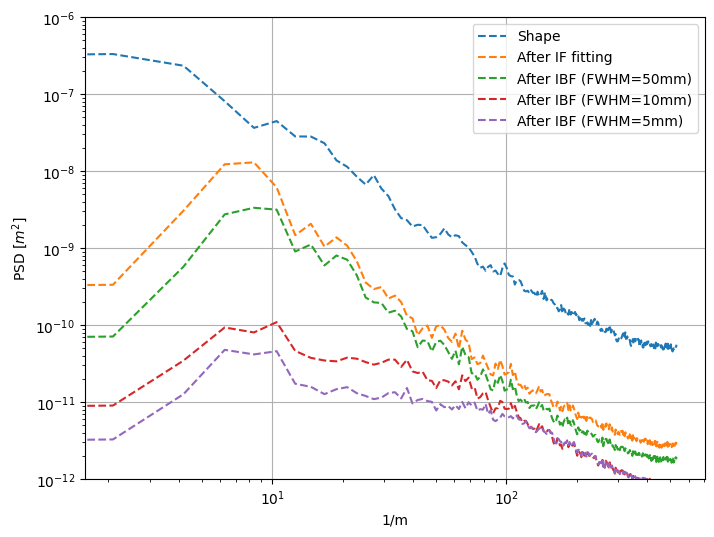

In [27]:
plt.figure(figsize=(8,6))
plt.plot(kpix/pix_scale,psd_img,'--',label='Shape')
plt.plot(kpix/pix_scale,psd_diff,'--',label='After IF fitting')
plt.plot(kpix/pix_scale,psd_ibf50,'--',label='After IBF (FWHM=50mm)')
plt.plot(kpix/pix_scale,psd_ibf10,'--',label='After IBF (FWHM=10mm)')
plt.plot(kpix/pix_scale,psd_ibf5,'--',label='After IBF (FWHM=5mm)')
plt.legend()
plt.ylim([1e-12,1e-6])
plt.xlabel('1/m')
plt.ylabel(r'PSD [$m^2$]')
plt.xscale('log')
plt.yscale('log')
plt.grid()

In [24]:
# psd_img, dpix = get_img_rad_profile(avg_img_2d, master_mask)
# psd_diff, dpix = get_img_rad_profile(diff, master_mask)
# psd_ibf13, dpix = get_img_rad_profile(ibf13_img, master_mask)
# psd_ibf10, dpix = get_img_rad_profile(ibf10_img, master_mask)
# psd_ibf6, dpix = get_img_rad_profile(ibf6_img, master_mask)
# psd_ibf2, dpix = get_img_rad_profile(ibf2_img, master_mask)

In [25]:
# plt.figure(figsize=(8,6))
# plt.plot(dpix,psd_img,'--',label='Shape')
# plt.plot(dpix,psd_diff,'--',label='After IF fitting')
# plt.plot(dpix,psd_ibf13,'--',label='After IBF (FWHM=13mm)')
# plt.plot(dpix,psd_ibf10,'--',label='After IBF (FWHM=10mm)')
# plt.plot(dpix,psd_ibf6,'--',label='After IBF (FWHM=6mm)')
# # plt.plot(dpix,psd_ibf2,'--',label='After IBF (FWHM=2mm)')
# plt.legend()
# # plt.xlim([0.1,20])
# # plt.xlabel('1/m')
# plt.ylabel(r'PSD [$m^2$]')
# plt.xscale('log')
# plt.yscale('log')
# plt.grid()